In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Fraud_check.csv")
df
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Undergrad        600 non-null    object
 1   Marital.Status   600 non-null    object
 2   Taxable.Income   600 non-null    int64 
 3   City.Population  600 non-null    int64 
 4   Work.Experience  600 non-null    int64 
 5   Urban            600 non-null    object
dtypes: int64(3), object(3)
memory usage: 28.2+ KB


0

In [39]:
# Assuming the target variable is 'Taxable.Income' and we want to classify as "Risky" or "Good"
df['Income_Category'] = df['Taxable.Income'].apply(lambda x: 'Risky' if x <= 30000 else 'Good')

In [40]:
df = df.drop('Taxable.Income', axis=1)

In [41]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
categorical_columns = ['Undergrad', 'Marital.Status', 'Urban', 'Income_Category']
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

<Figure size 1500x1000 with 0 Axes>

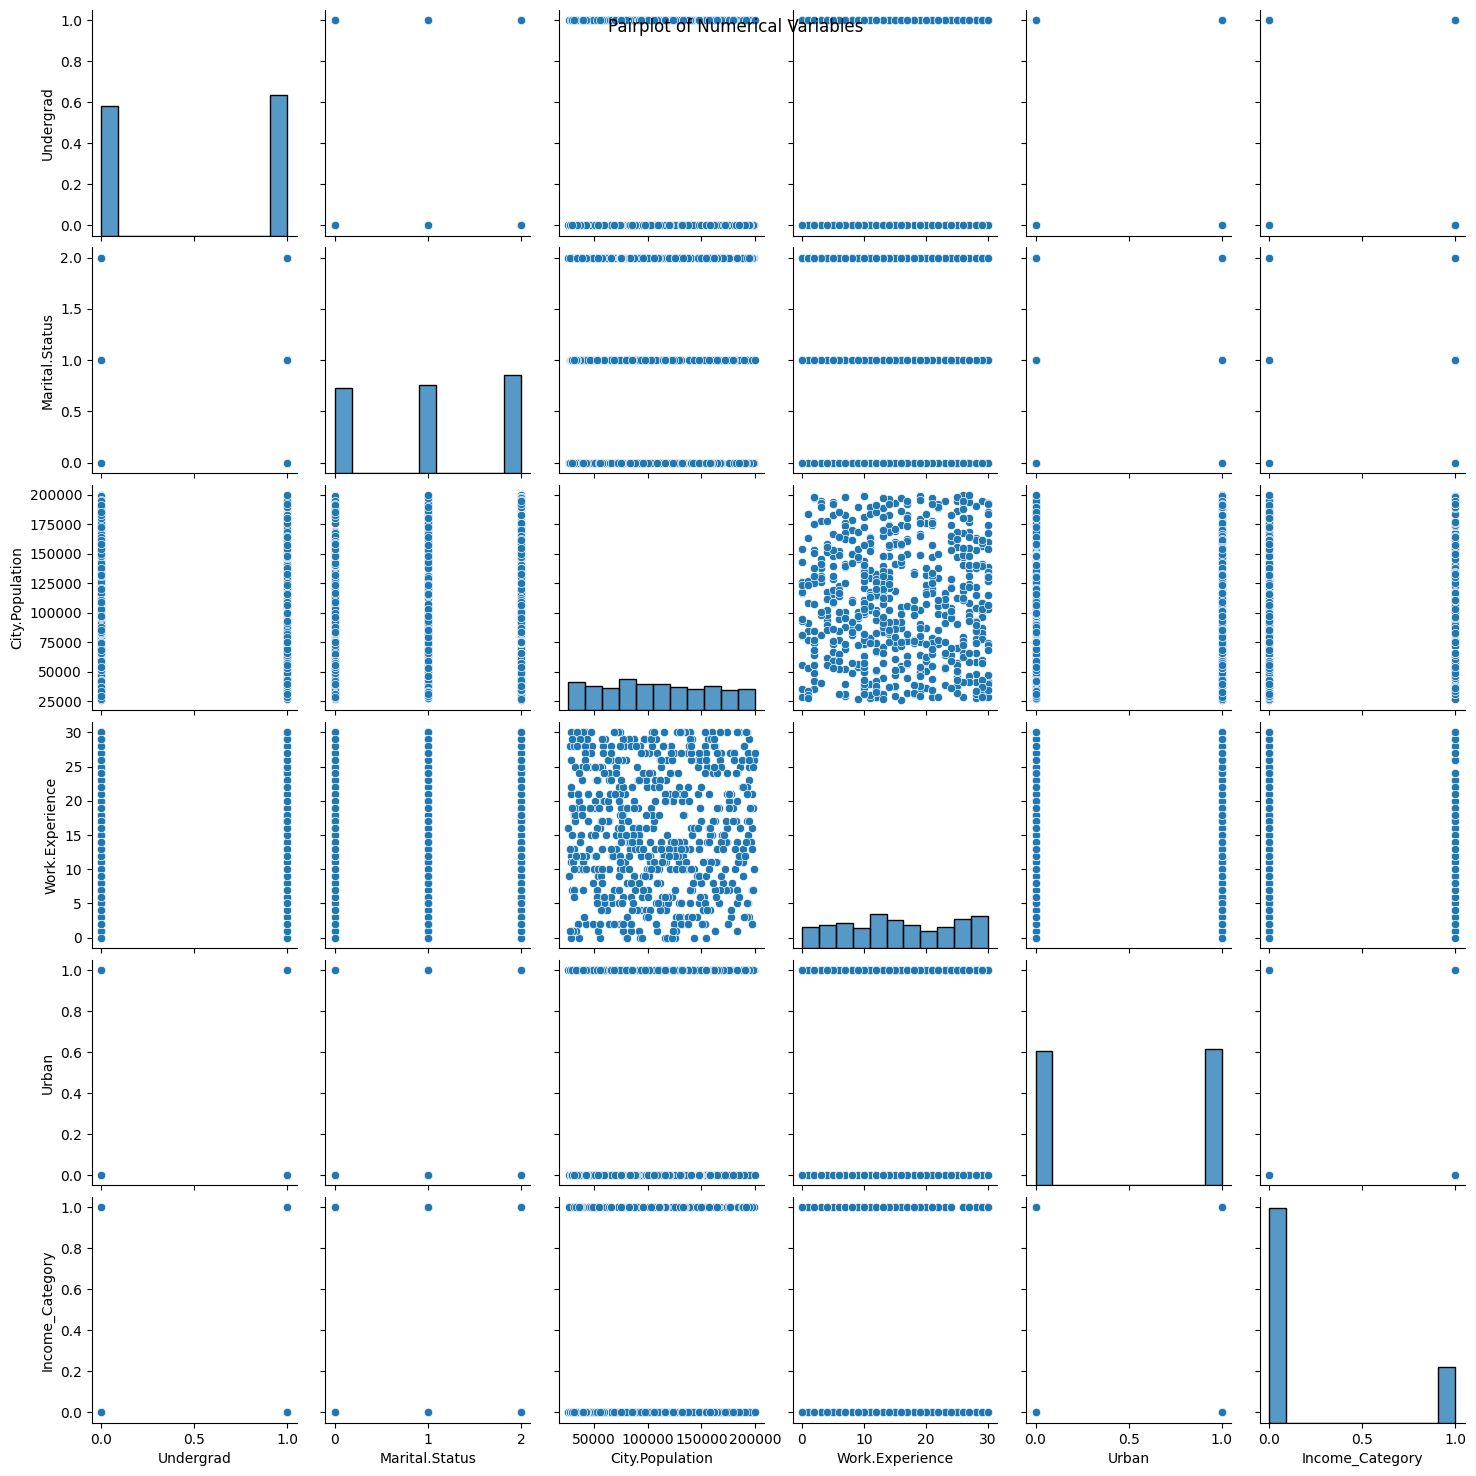

In [42]:
# Pairplot
plt.figure(figsize=(15, 10))
sns.pairplot(df)
plt.suptitle('Pairplot of Numerical Variables ')
plt.show()

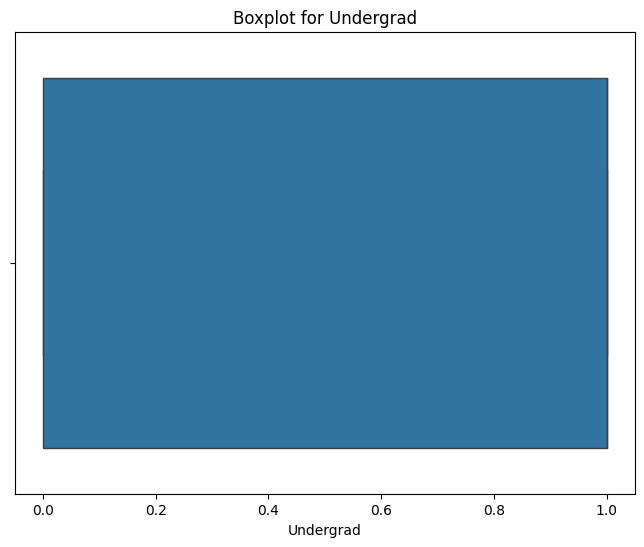

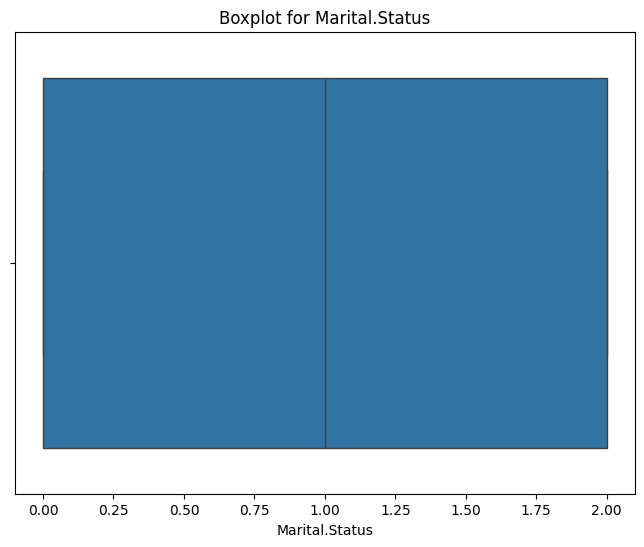

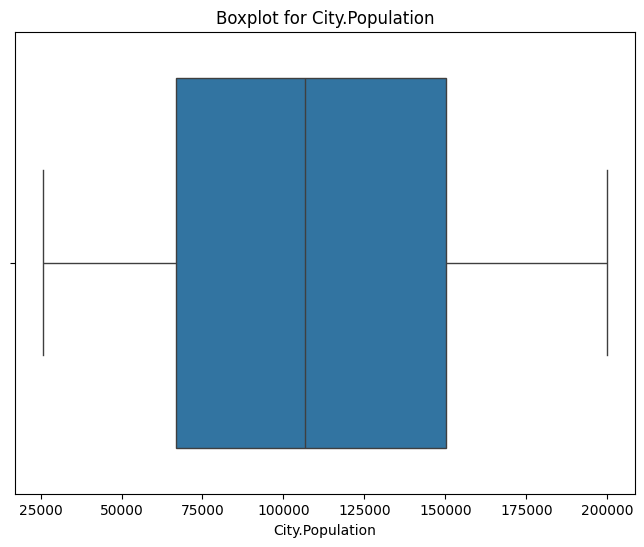

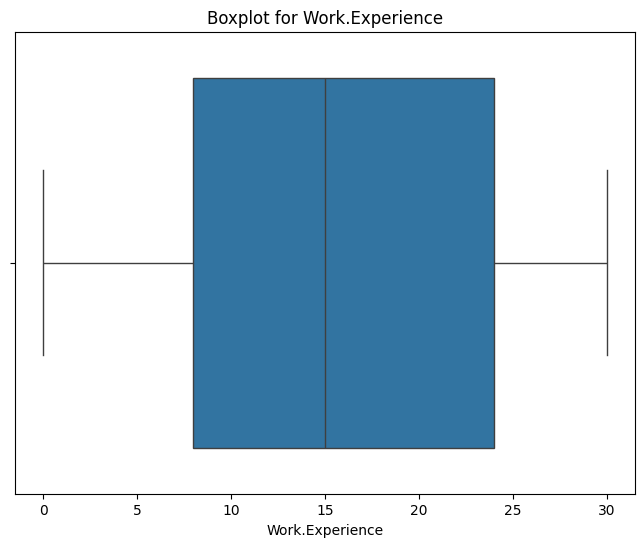

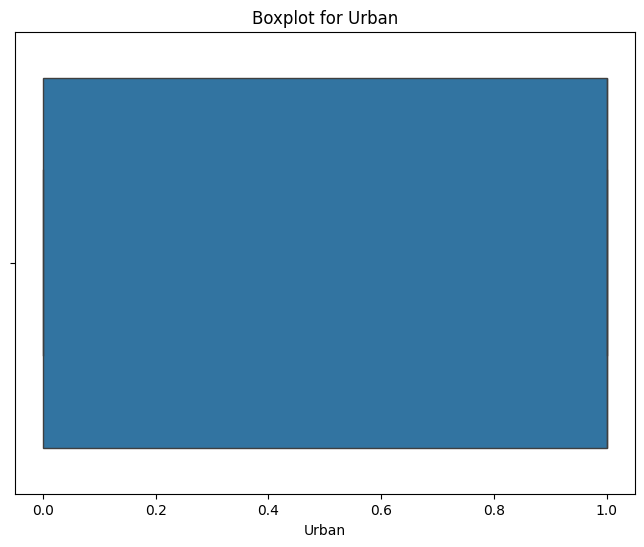

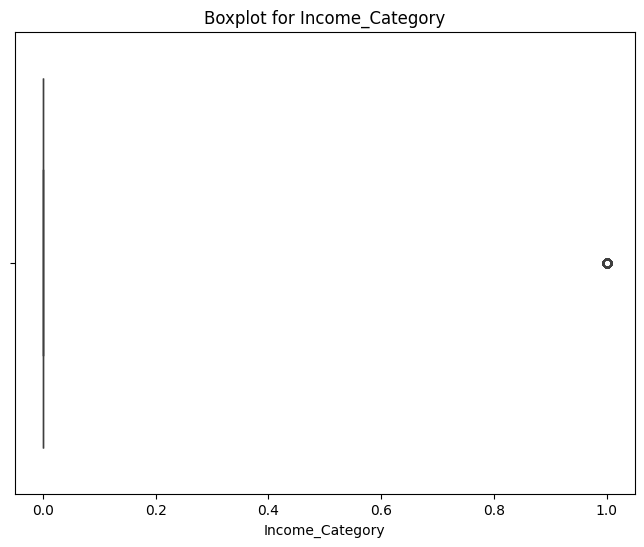

In [43]:
#boxplot
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()


In [44]:
X = df.drop('Income_Category', axis=1)
y = df['Income_Category']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [46]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [47]:
y_pred = random_forest.predict(X_test)

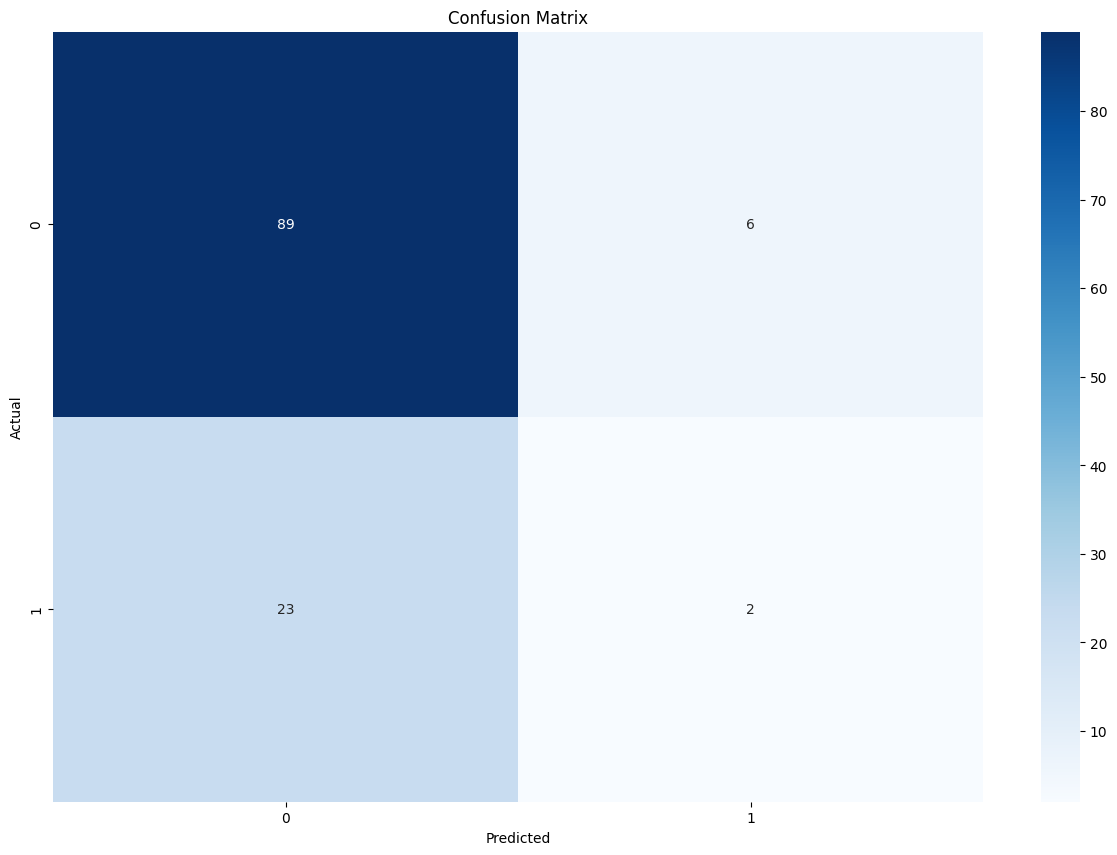

In [48]:
plt.figure(figsize=(15, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

In [50]:
print('Accuracy:', accuracy)
print('Confusion Matrix:', conf_matrix)
print('Classification Report:', classification_rep)

Accuracy: 0.7583333333333333
Confusion Matrix: [[89  6]
 [23  2]]
Classification Report:               precision    recall  f1-score   support

           0       0.79      0.94      0.86        95
           1       0.25      0.08      0.12        25

    accuracy                           0.76       120
   macro avg       0.52      0.51      0.49       120
weighted avg       0.68      0.76      0.71       120



In [51]:
tree_rules = export_text(decision_tree, feature_names=list(X.columns))
print('Decision Tree Rules:', tree_rules)


Decision Tree Rules: |--- Work.Experience <= 24.50
|   |--- City.Population <= 197770.00
|   |   |--- Work.Experience <= 14.50
|   |   |   |--- Work.Experience <= 11.50
|   |   |   |   |--- City.Population <= 27057.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- City.Population >  27057.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- Work.Experience >  11.50
|   |   |   |   |--- Work.Experience <= 13.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Work.Experience >  13.50
|   |   |   |   |   |--- class: 0
|   |   |--- Work.Experience >  14.50
|   |   |   |--- City.Population <= 135912.50
|   |   |   |   |--- City.Population <= 124584.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- City.Population >  124584.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- City.Population >  135912.50
|   |   |   |   |--- City.Population <= 149214.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- City.Population >  149214.00
|   |   |   |   |   |--- class: